# Arbitrage index

Given the reference trade sizes, price the executable cross-pool round trip and
summarize it into a per-pool-pair arbitrage index. Parameters come from
`arblib.config.STUDY`.

In [1]:
from arblib import data_io, analysis, sizing, arbitrage, modeling, plotting
from arblib.config import STUDY as S

pools = data_io.load_processed_pools(S.processed_dir)
analysis.add_mid_price(pools)

x_usd = data_io.load_price_series(S.x_price_path)
y_usd = data_io.load_price_series(S.y_price_path)
price0, price1 = sizing.constant_usd_prices(x_usd, y_usd)

quantiles = data_io.load_quantiles(S.quantiles_path)
print(quantiles)

/Users/matthieu/Downloads/DeFi_limits-to-arbitrage/arblib/data_io.py:108: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, skipinitialspace=True)


Loaded 6 processed pools: ['uniswap_1', 'uniswap_2', 'uniswap_3', 'uniswap_4', 'pancake_1', 'pancake_2']
quantile
0.2      25.305772
0.4      98.297823
0.6     381.251111
0.8    2552.089436
Name: usd, dtype: float64


/Users/matthieu/Downloads/DeFi_limits-to-arbitrage/arblib/data_io.py:108: DtypeWarning: Columns (2,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, skipinitialspace=True)


## 1. Cross-DEX mid-price gaps

The raw opportunity before execution costs: per-pool mid prices and the absolute
price difference for every cross-DEX pool pair.

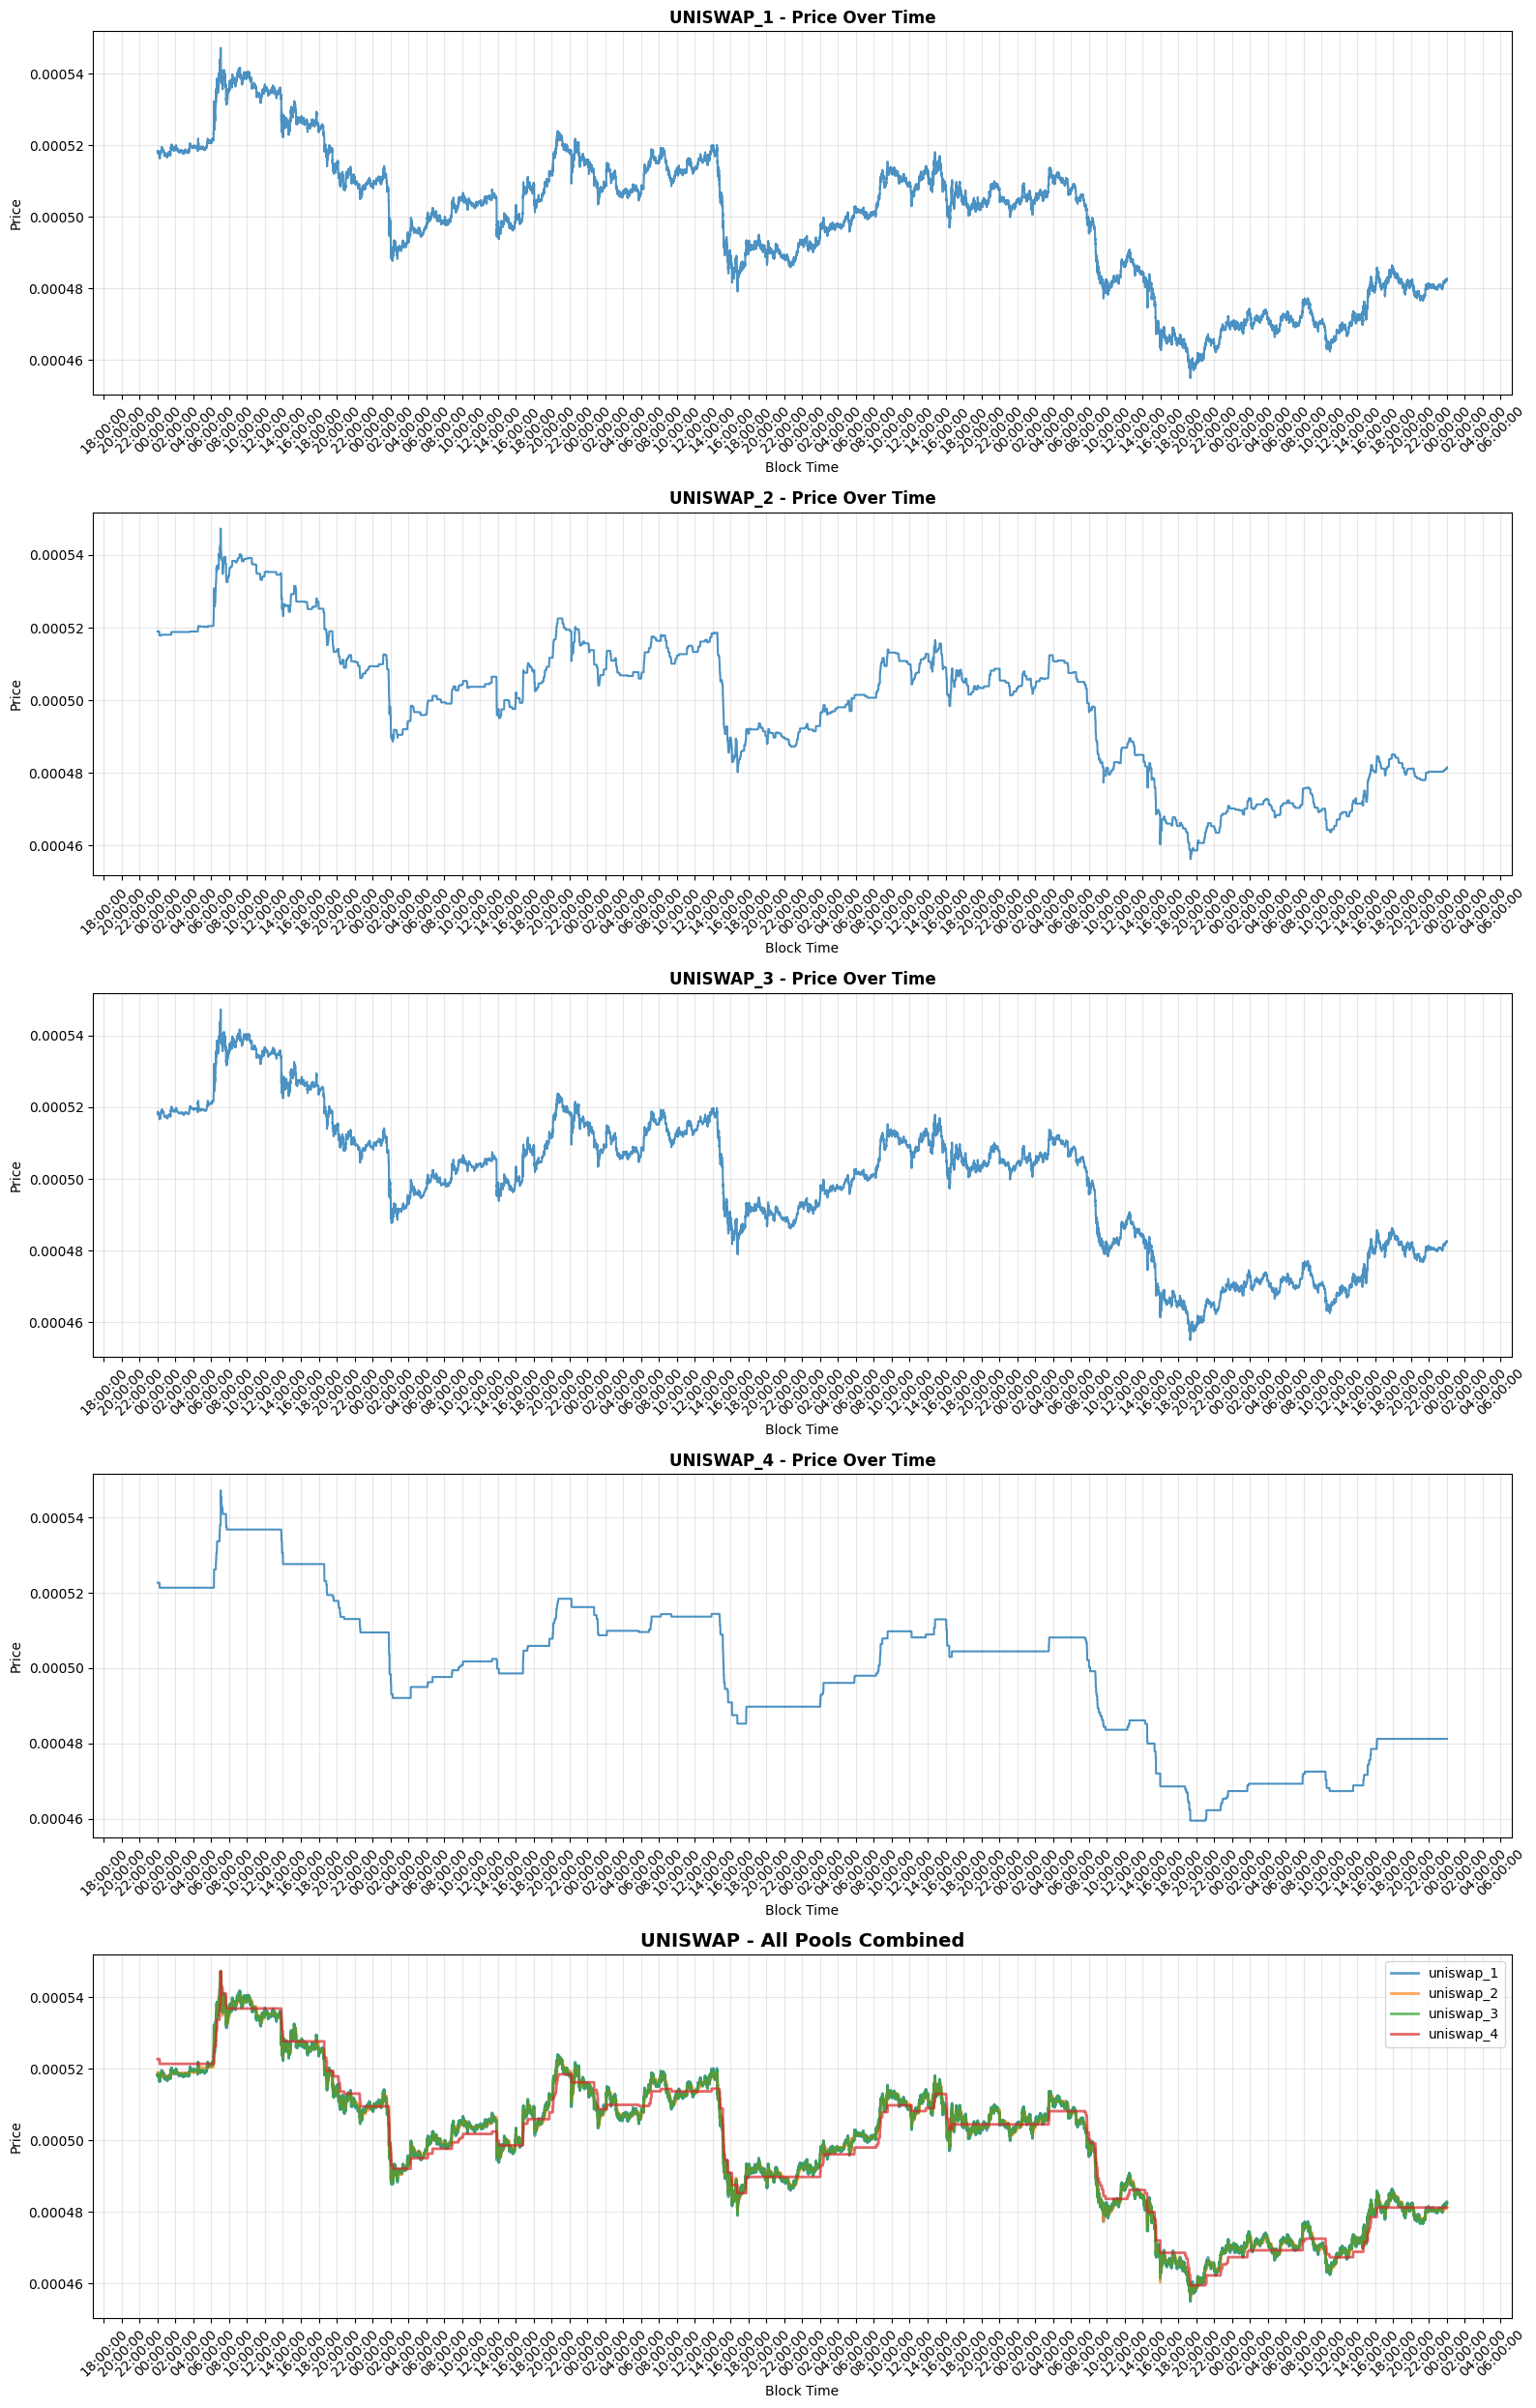


Plotted 4 uniswap pools + 1 combined view
  uniswap_1: 42996 blocks
  uniswap_2: 42996 blocks
  uniswap_3: 42996 blocks
  uniswap_4: 42996 blocks


In [2]:
plotting.plot_dex_pools(pools, dex="uniswap")

In [3]:
price_differences, all_price_differences = analysis.compute_pairwise_differences(pools)

DEXes found: ['uniswap', 'pancake']
Pools per DEX: [('uniswap', 4), ('pancake', 2)]

Computed 8 pairwise comparisons:

uniswap_1_vs_pancake_1:
  Rows: 42996
  Max diff: 0.000008
  Mean diff: 0.000000
  Min diff: 0.000000

uniswap_1_vs_pancake_2:
  Rows: 42996
  Max diff: 0.000008
  Mean diff: 0.000000
  Min diff: 0.000000

uniswap_2_vs_pancake_1:
  Rows: 42996
  Max diff: 0.000007
  Mean diff: 0.000001
  Min diff: 0.000000

uniswap_2_vs_pancake_2:
  Rows: 42996
  Max diff: 0.000006
  Mean diff: 0.000001
  Min diff: 0.000000

uniswap_3_vs_pancake_1:
  Rows: 42996
  Max diff: 0.000007
  Mean diff: 0.000000
  Min diff: 0.000000

uniswap_3_vs_pancake_2:
  Rows: 42996
  Max diff: 0.000007
  Mean diff: 0.000000
  Min diff: 0.000000

uniswap_4_vs_pancake_1:
  Rows: 42996
  Max diff: 0.000009
  Mean diff: 0.000002
  Min diff: 0.000000

uniswap_4_vs_pancake_2:
  Rows: 42996
  Max diff: 0.000008
  Mean diff: 0.000002
  Min diff: 0.000000

Combined difference dataframe shape: (42996, 10)


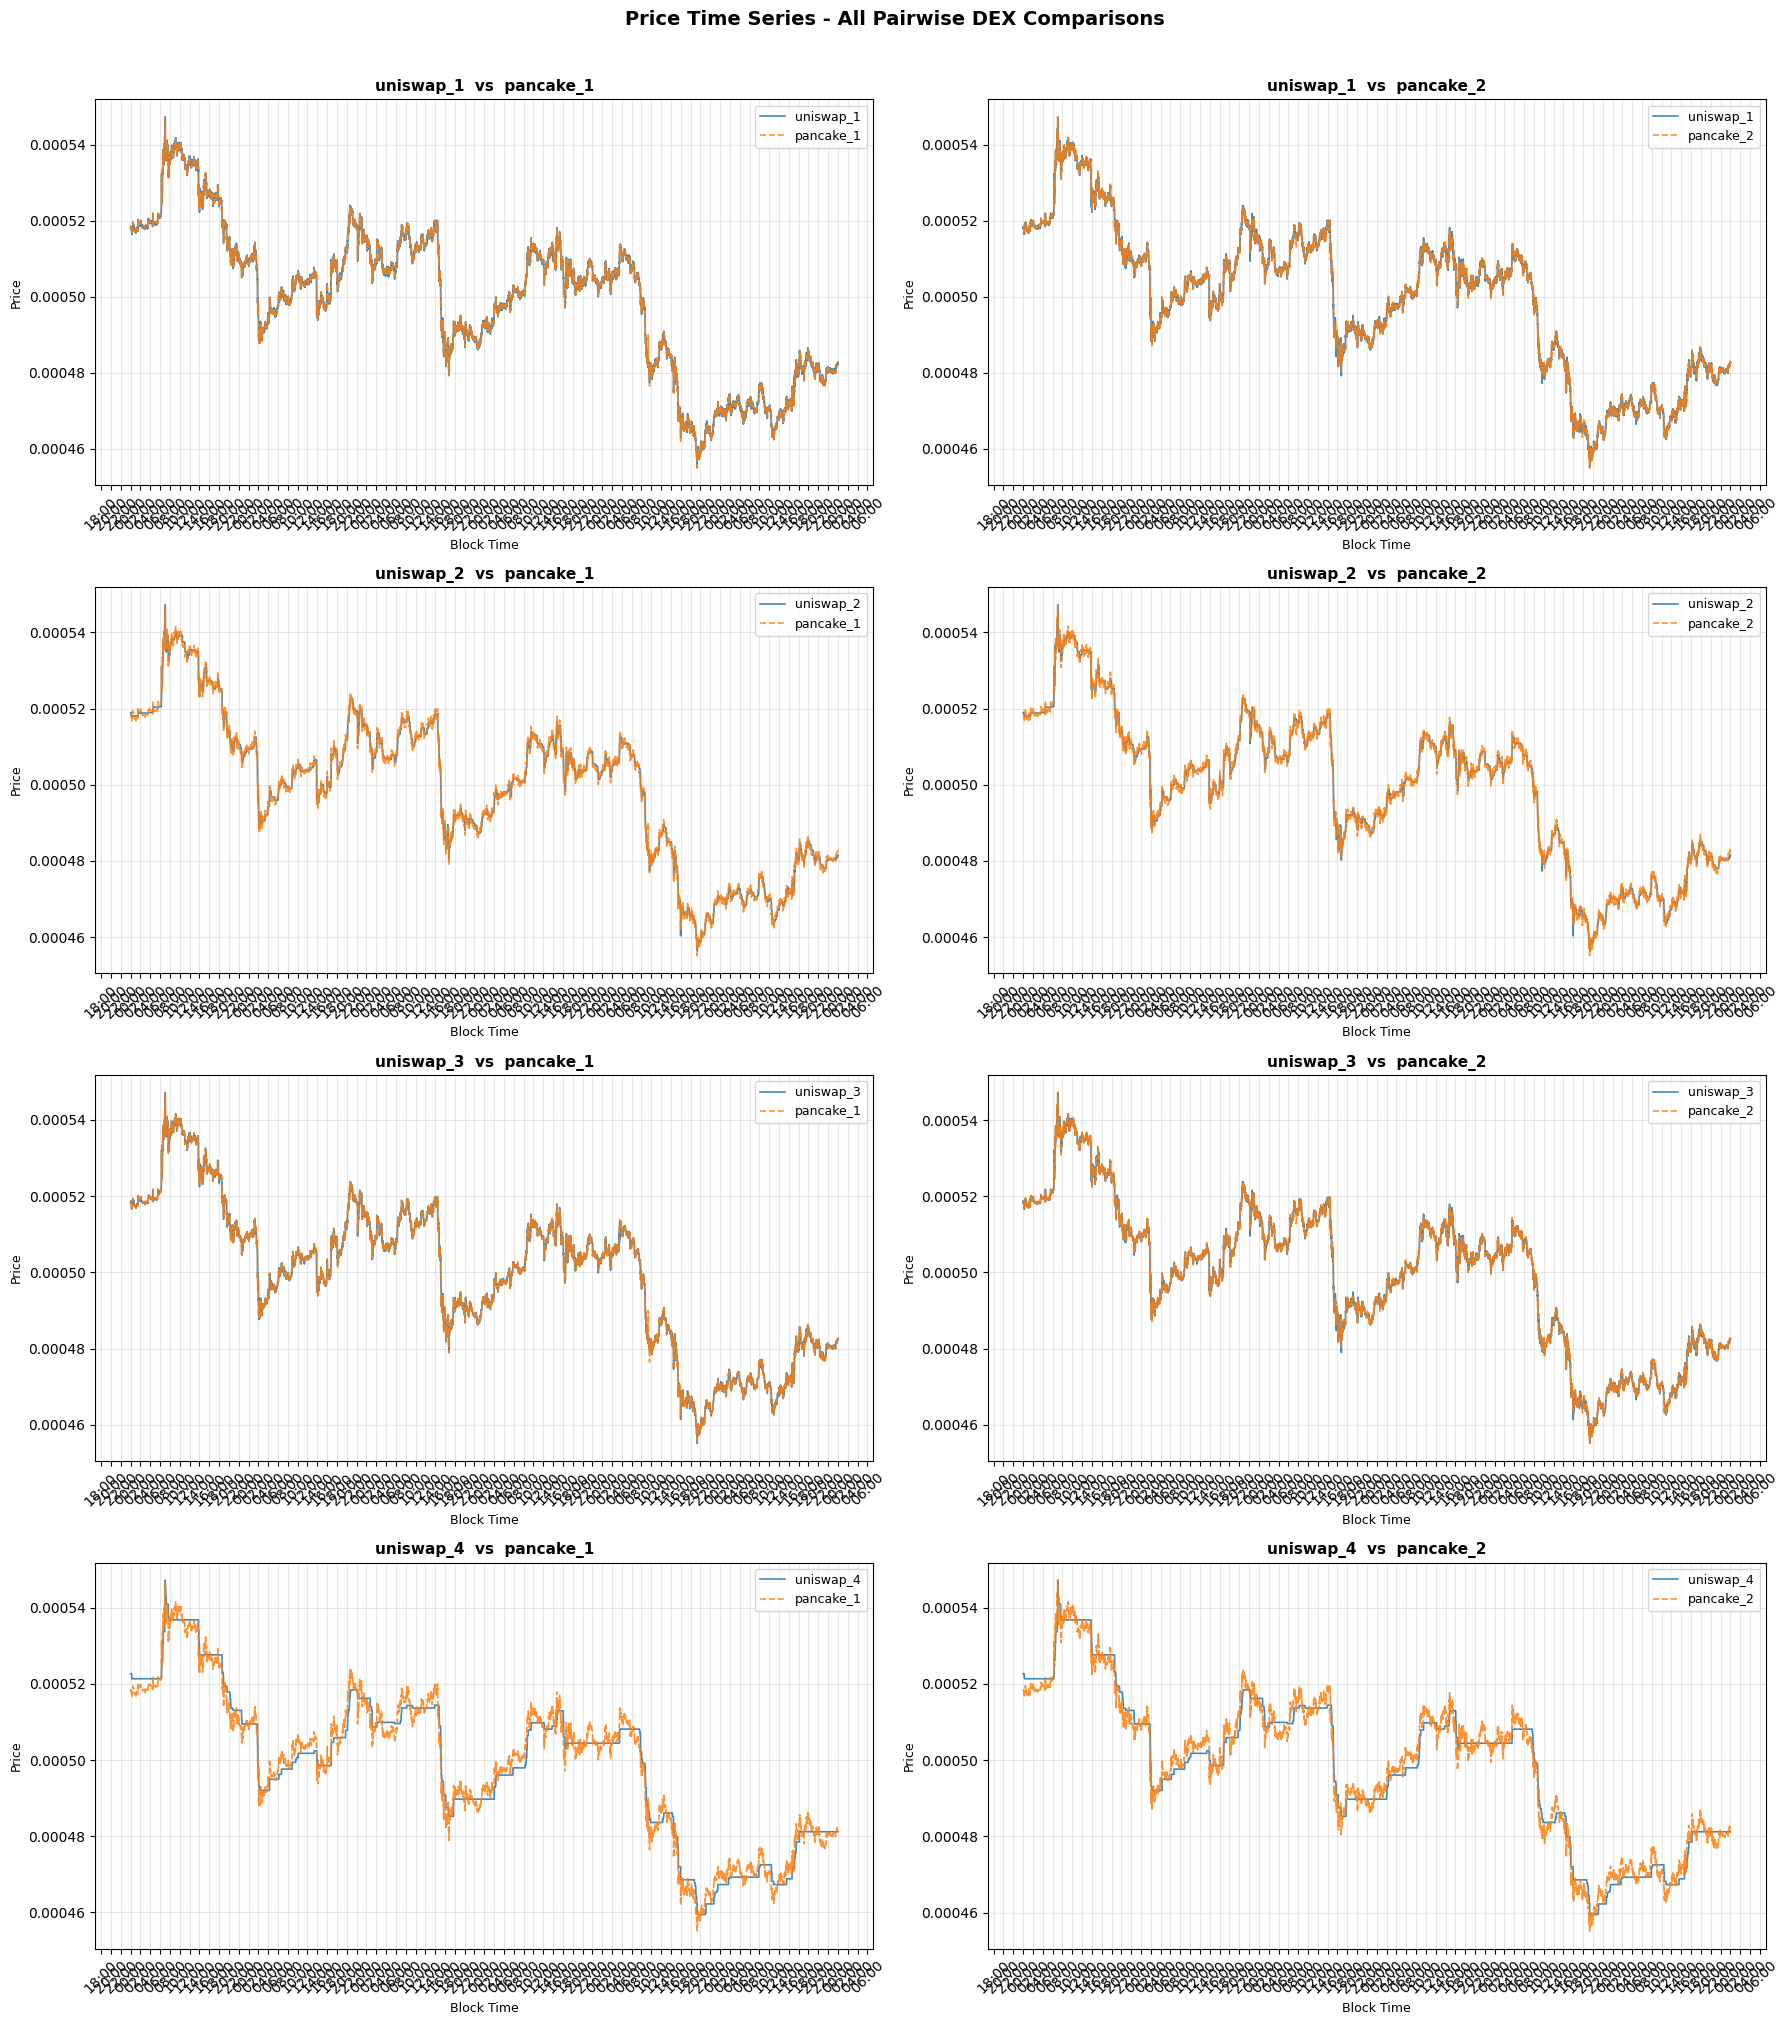

In [4]:
plotting.plot_pairwise_prices(price_differences)

## 2. Pick a pool pair

Bundle two pools' per-block state + market context into a `PoolPair`.

In [5]:
pair = arbitrage.build_pool_pair(
    pools["pancake_1"], pools["uniswap_1"], S.token0, S.token1, price0, price1, "pancake_1", "uniswap_1"
)

## 3a. Round-trip spreads at each reference trade size

Two panels per size (direction 1→2 and 2→1, Y- and X-anchored). A series below
zero is a profitable round trip after both fees + slippage.

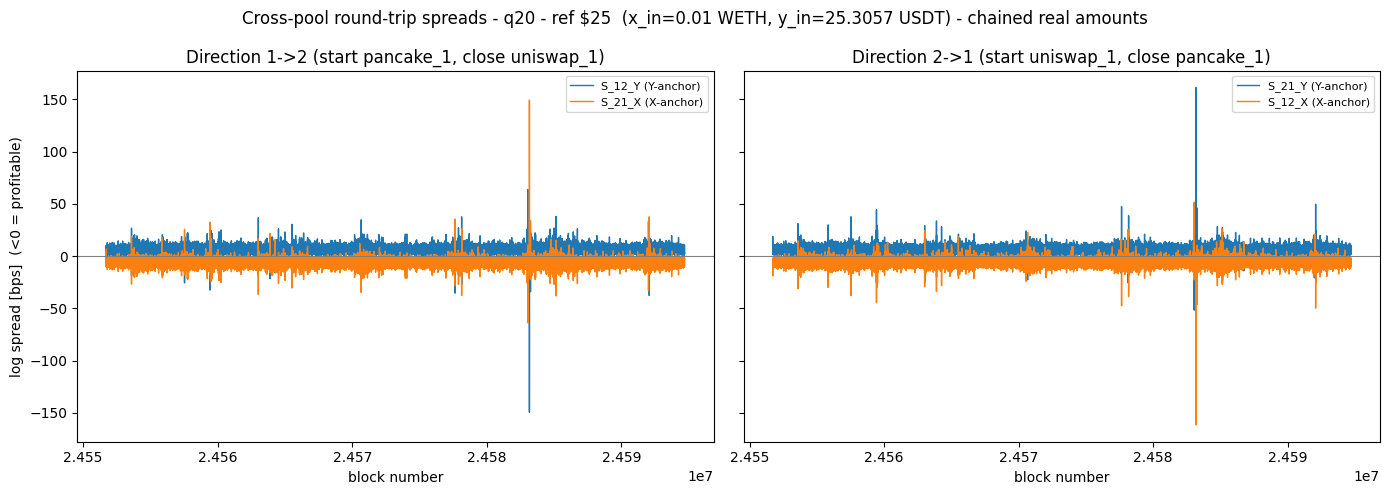

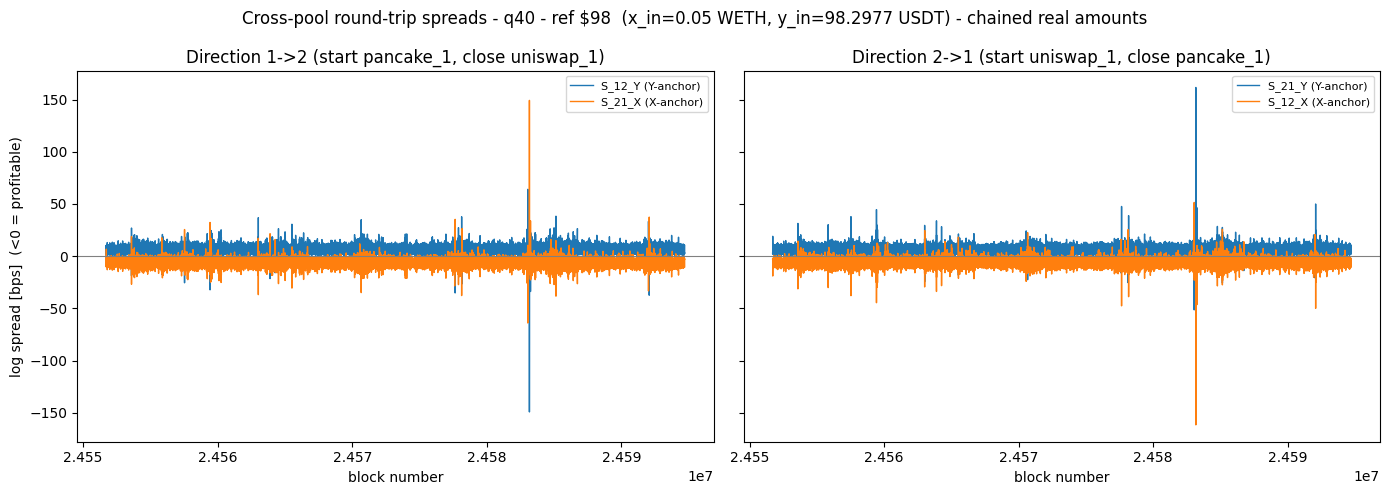

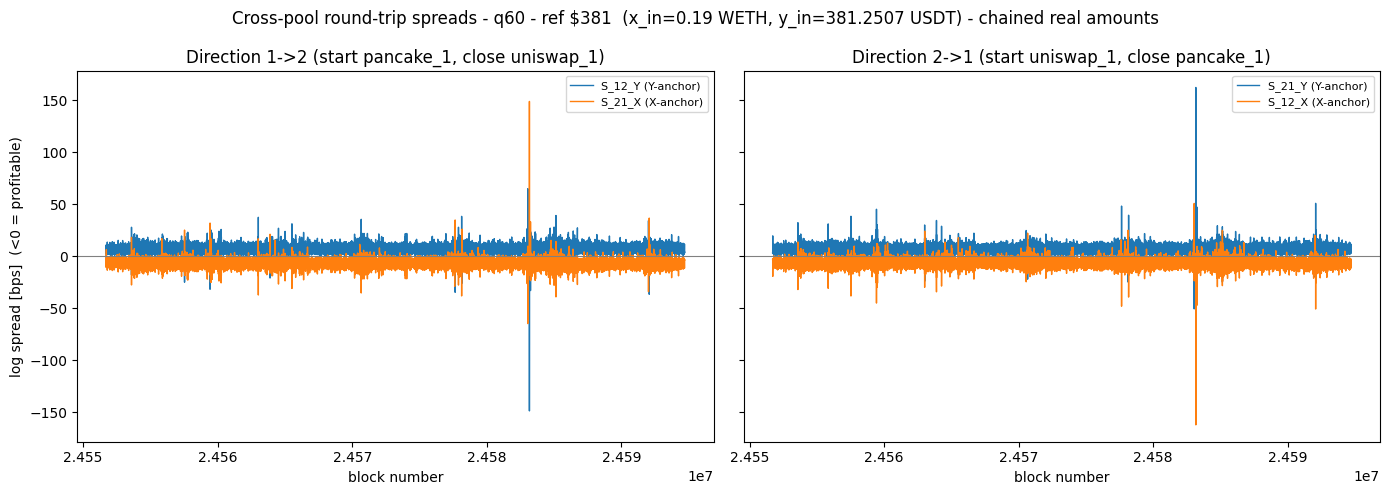

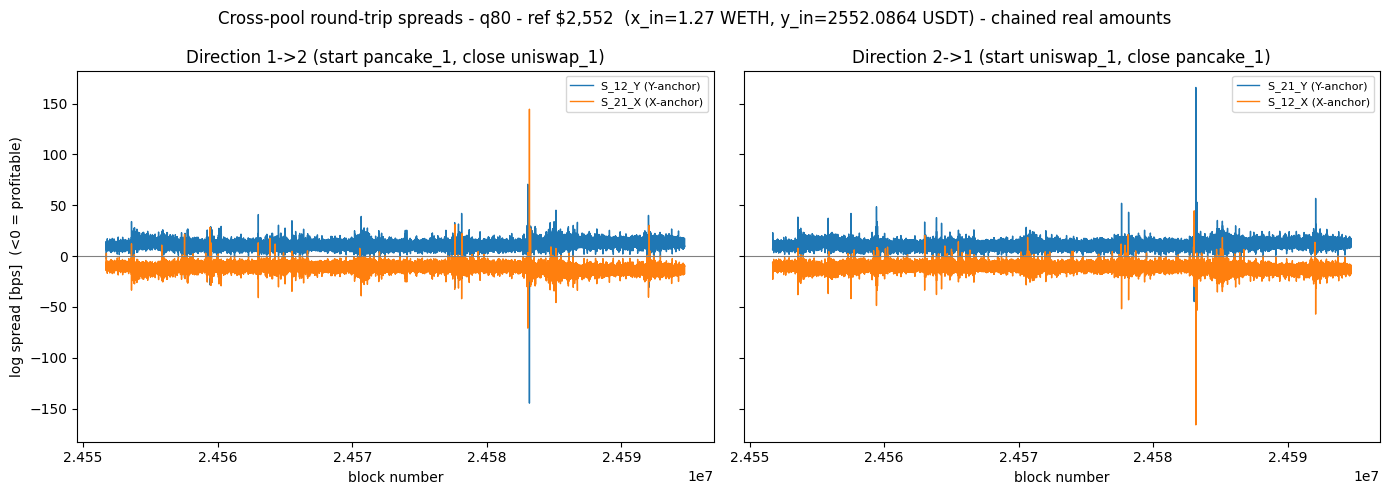

In [6]:
for q, Q in quantiles.items():
    plotting.plot_directional_spreads(pair, Q, f"Cross-pool round-trip spreads - q{int(q * 100)}")

## 3b. Custom trade size

Pass exactly one of `usd_amount` / `x_amount` (token0) / `y_amount` (token1).

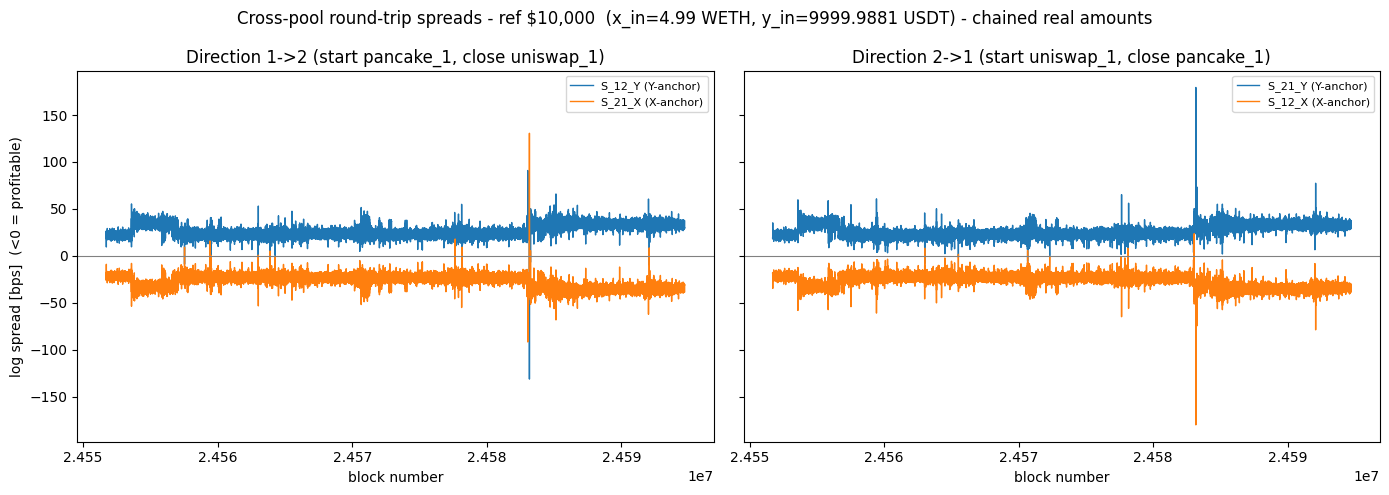

In [7]:
plotting.plot_custom_size(pair, usd_amount=10_000, title_prefix="Cross-pool round-trip spreads")

## 4. Arbitrage index (all pool pairs)

`all_pairs_gap_series` stores the per-block round-trip gap `Gap_t` (bps) for **every**
pool pair — intra-DEX (e.g. `uniswap_1_vs_uniswap_5`) as well as cross-DEX.
`arb_index["<poolA>_vs_<poolB>"]` is a blocks × trade-sizes frame; `arbitrage_index`
below summarises one pair across blocks.

In [8]:
arb_index = arbitrage.all_pairs_gap_series(pools, quantiles, S.token0, S.token1, price0, price1)
print("pairs:", list(arb_index))




pairs: ['uniswap_1_vs_uniswap_2', 'uniswap_1_vs_uniswap_3', 'uniswap_1_vs_uniswap_4', 'uniswap_1_vs_pancake_1', 'uniswap_1_vs_pancake_2', 'uniswap_2_vs_uniswap_3', 'uniswap_2_vs_uniswap_4', 'uniswap_2_vs_pancake_1', 'uniswap_2_vs_pancake_2', 'uniswap_3_vs_uniswap_4', 'uniswap_3_vs_pancake_1', 'uniswap_3_vs_pancake_2', 'uniswap_4_vs_pancake_1', 'uniswap_4_vs_pancake_2', 'pancake_1_vs_pancake_2']


In [9]:
counts_02 = {
    pair: (df[0.2] > 0).sum()
    for pair, df in arb_index.items()
}

counts_02

{'uniswap_1_vs_uniswap_2': np.int64(173),
 'uniswap_1_vs_uniswap_3': np.int64(2658),
 'uniswap_1_vs_uniswap_4': np.int64(755),
 'uniswap_1_vs_pancake_1': np.int64(2209),
 'uniswap_1_vs_pancake_2': np.int64(14925),
 'uniswap_2_vs_uniswap_3': np.int64(17),
 'uniswap_2_vs_uniswap_4': np.int64(10),
 'uniswap_2_vs_pancake_1': np.int64(17),
 'uniswap_2_vs_pancake_2': np.int64(185),
 'uniswap_3_vs_uniswap_4': np.int64(412),
 'uniswap_3_vs_pancake_1': np.int64(405),
 'uniswap_3_vs_pancake_2': np.int64(4647),
 'uniswap_4_vs_pancake_1': np.int64(463),
 'uniswap_4_vs_pancake_2': np.int64(237),
 'pancake_1_vs_pancake_2': np.int64(3973)}

In [10]:
arbitrage.arbitrage_index(pair, quantiles)

,usd_ref,n_blocks,live_gap_share,mean_gap_bps,median_gap_bps,max_gap_bps,anchor_agreement
quantile,,,,,,,
0.2,25.305772,42996,0.051377,0.115355,0.0,149.311996,0.999930
0.4,98.297823,42996,0.046818,0.107439,0.0,149.178637,0.999860
0.6,381.251111,42996,0.032282,0.083473,0.0,148.661687,0.999721
0.8,2552.089436,42996,0.004652,0.025750,0.0,144.696499,0.999977


In [11]:
# keep only pool pairs with >=1 arbitrage event at the smallest size (q0.2); drop the rest so the
# modeling parquets (dependent variable + pair covariates) never contain empty pairs
kept_pairs = [pair for pair, n in counts_02.items() if n > 0]
dropped_pairs = [pair for pair, n in counts_02.items() if n == 0]
arb_index = {pair: arb_index[pair] for pair in kept_pairs}
print(f"kept {len(kept_pairs)} pairs with >=1 event; dropped {len(dropped_pairs)}: {dropped_pairs}")

kept 15 pairs with >=1 event; dropped 0: []


## 5. Any arbitrage in the sample?

Heatmap of the round-trip gap across all pairs and blocks, one panel per reference
trade size. Coloured cells are profitable round trips (after fees + slippage); a
near-blank map means little arbitrage at that size.

q20: 31086 live (pair, block) cells of 644940 | max gap = 149.31 bps


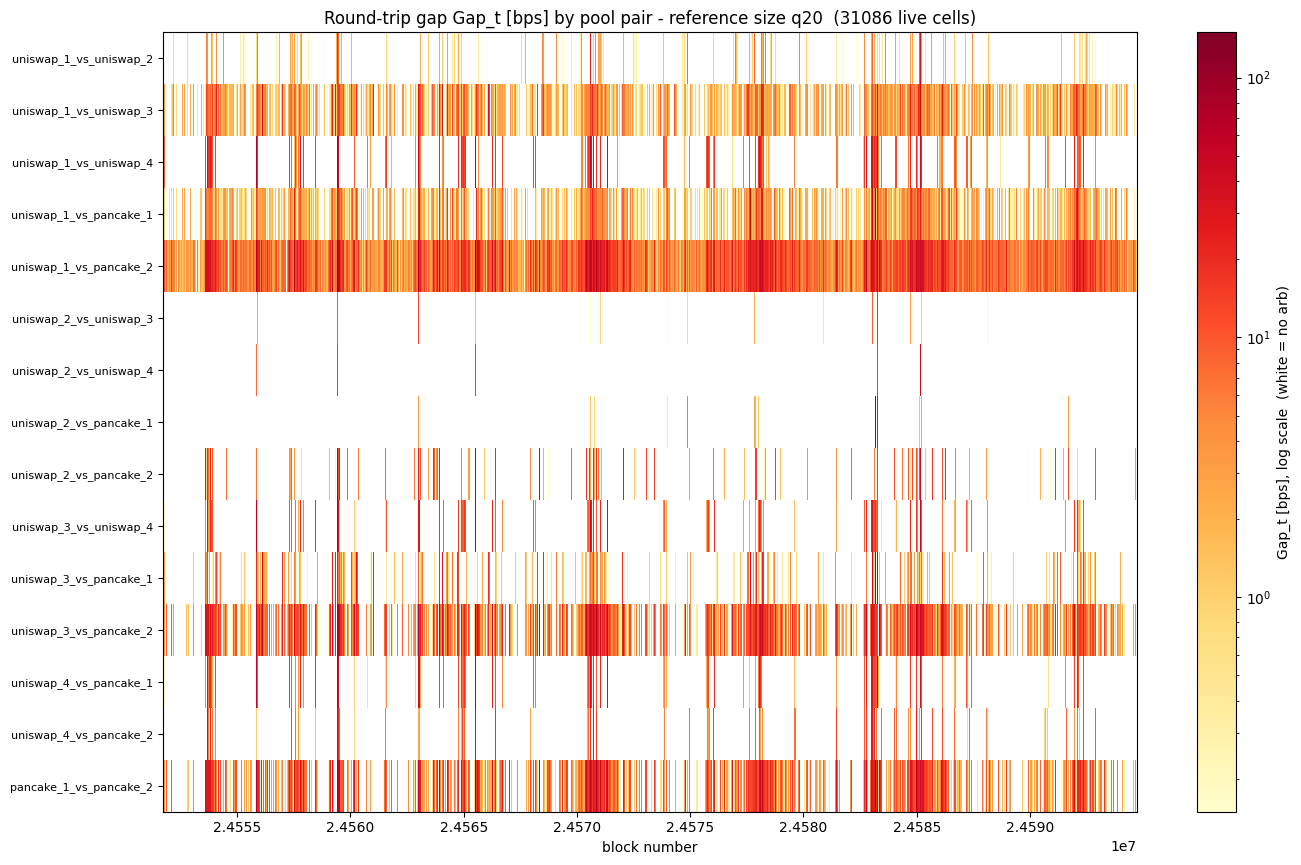

q40: 9758 live (pair, block) cells of 644940 | max gap = 149.18 bps


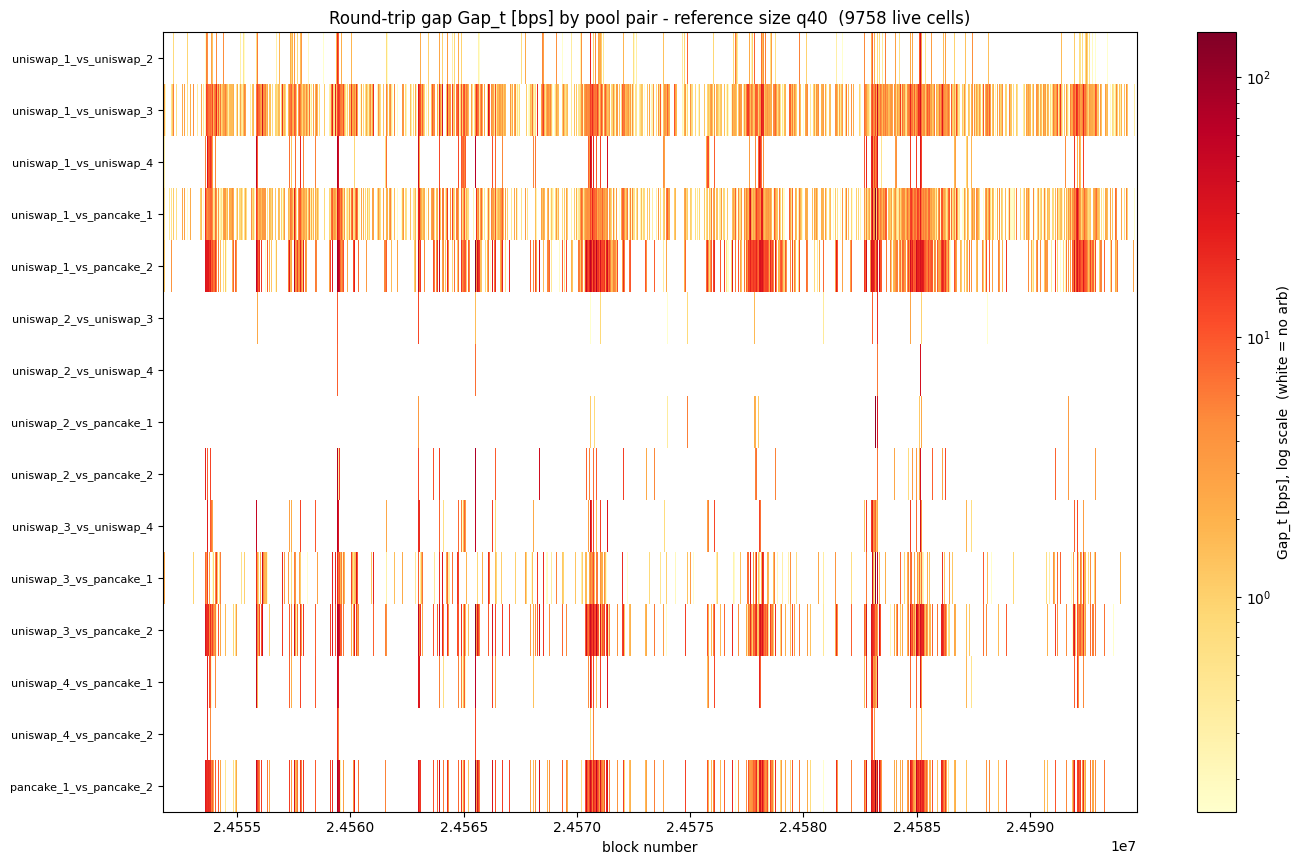

q60: 3899 live (pair, block) cells of 644940 | max gap = 148.66 bps


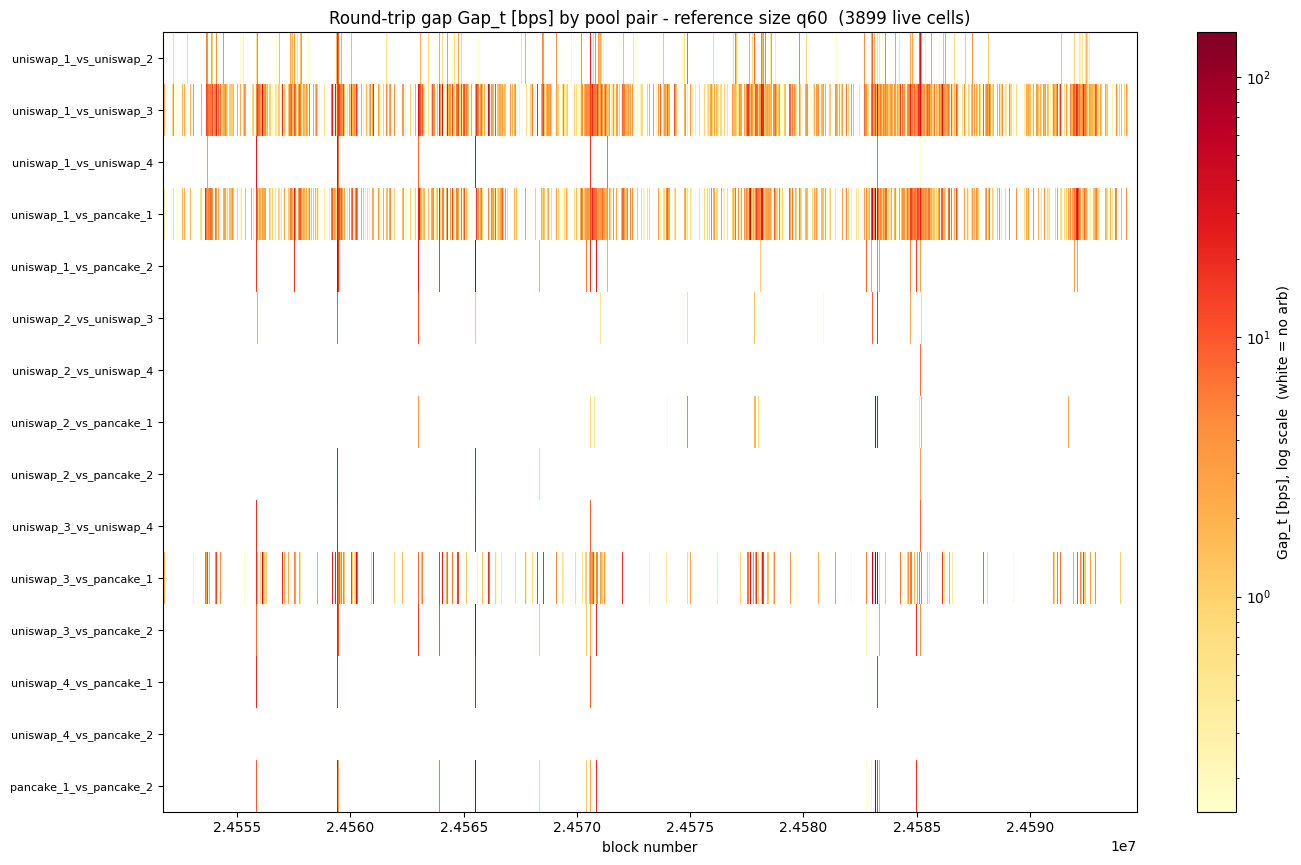

q80: 825 live (pair, block) cells of 644940 | max gap = 144.70 bps


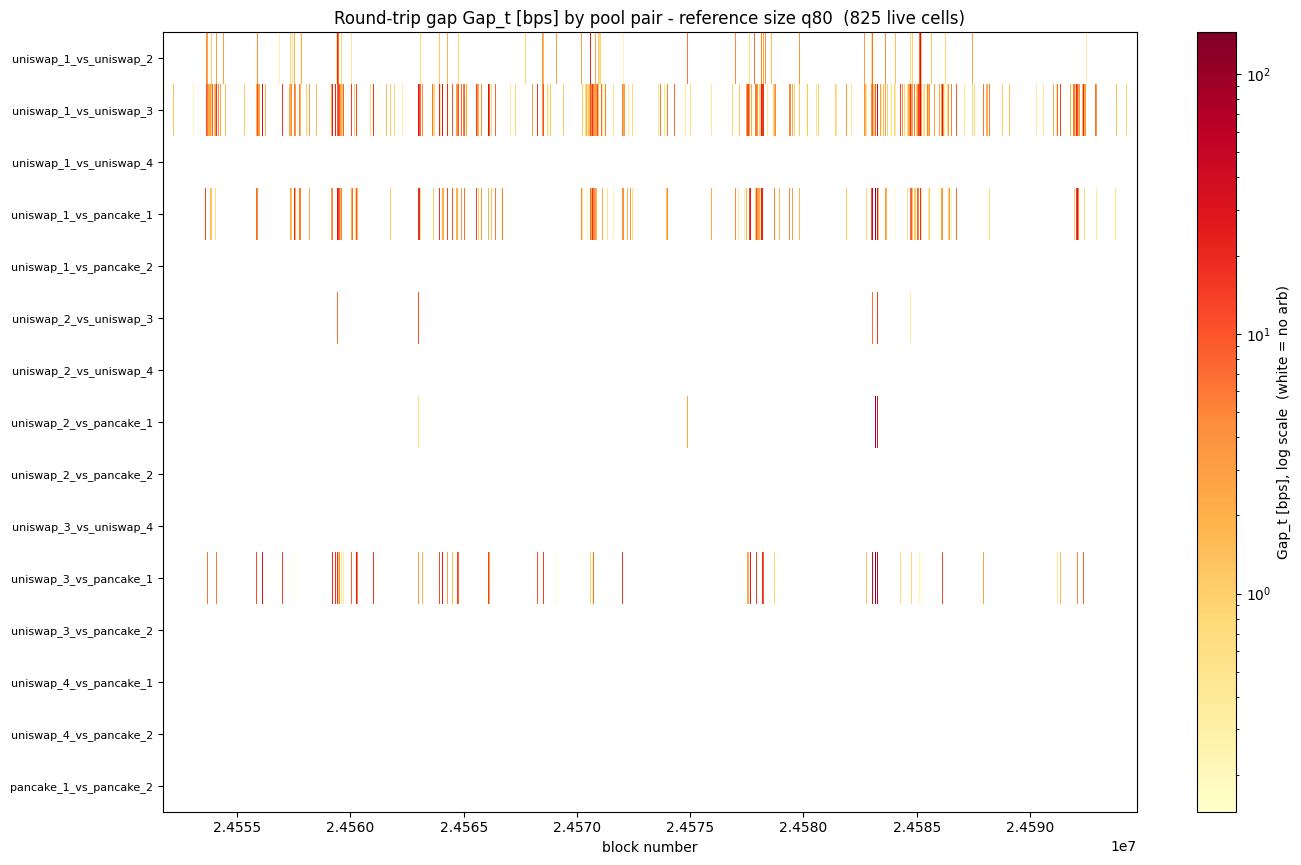

In [12]:
for q in quantiles.index:
    plotting.plot_arb_index(arb_index, q)

## 6. How long does arbitrage hold?

For each pool pair the index is live (`Gap_t > 0`) in runs of consecutive blocks — an arbitrage
*spell*. `arb_hold_durations` extracts every spell's length; `plot_arb_durations` draws, one graph per
trade size, each pair's duration sequence (x = spell index, y = duration).

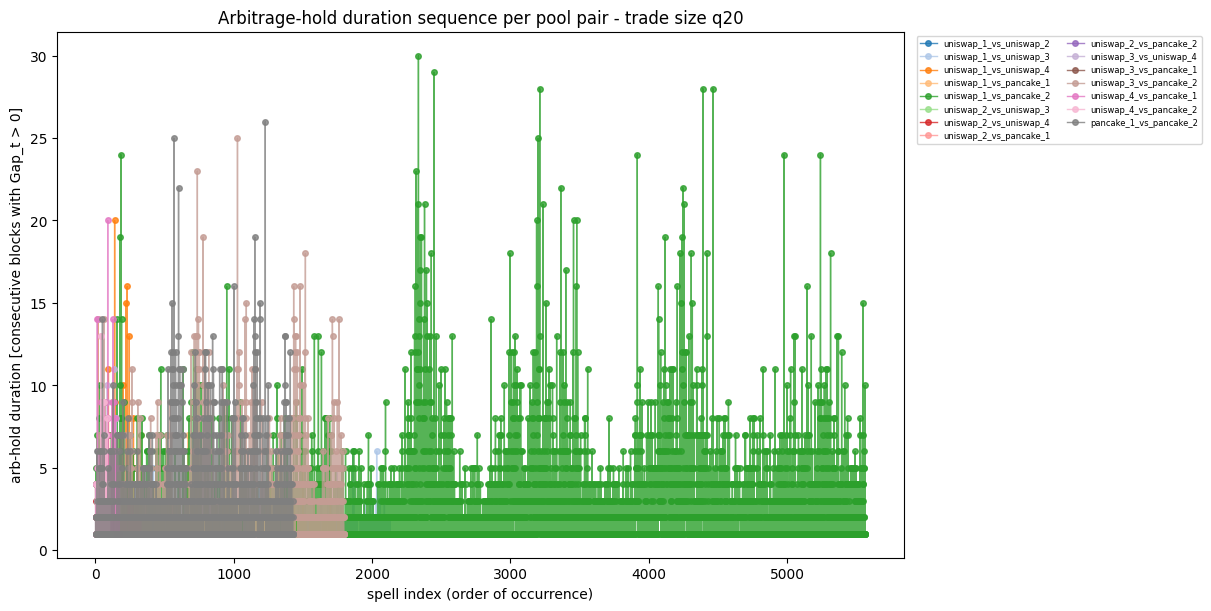

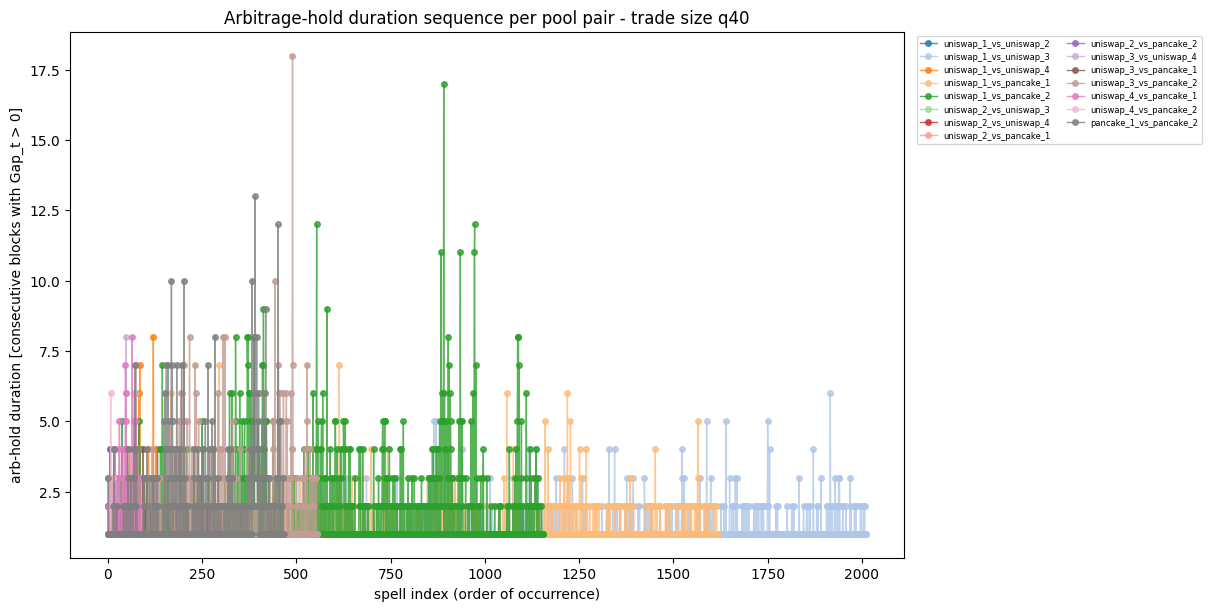

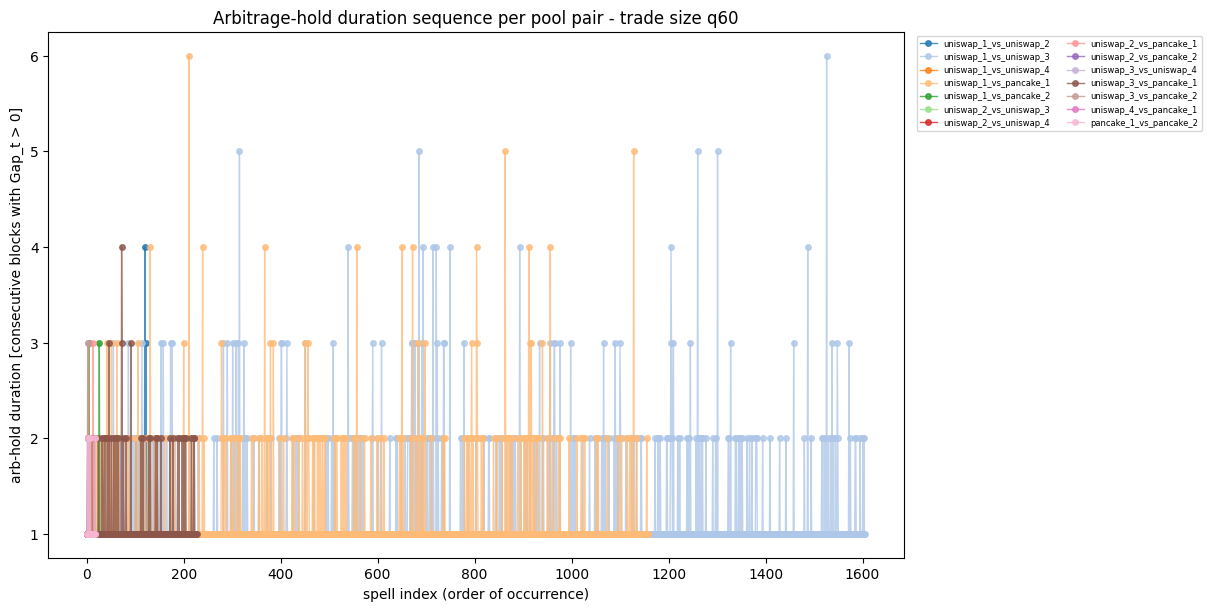

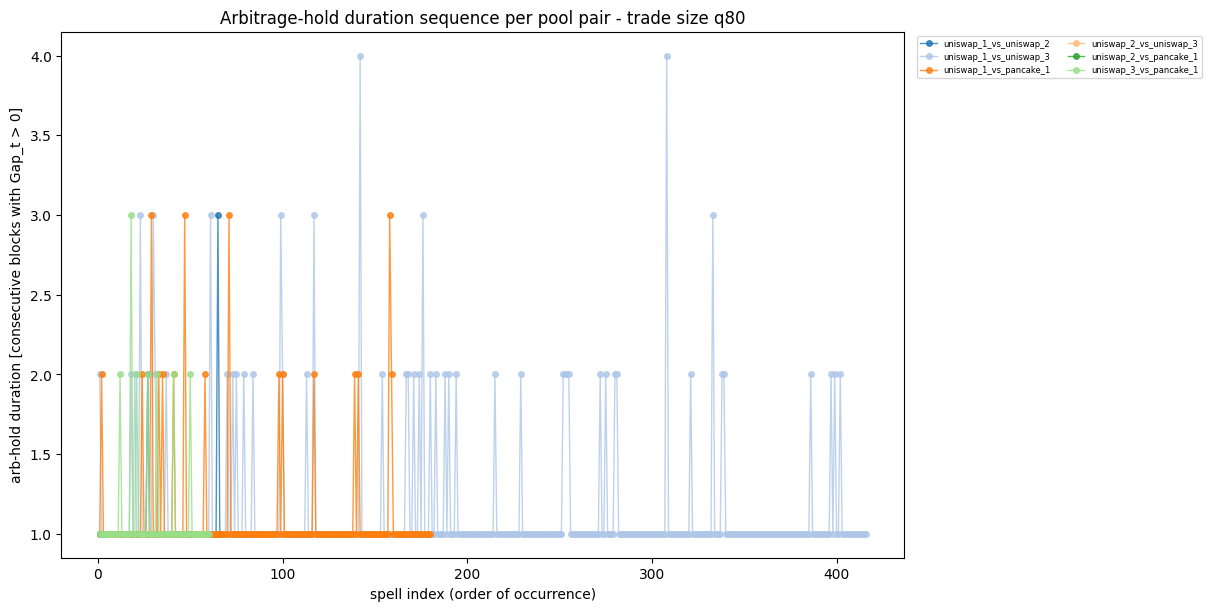

In [13]:
durations = arbitrage.arb_hold_durations(arb_index)
for q in quantiles.index:
    plotting.plot_arb_durations(durations, q)

## 7. Save the dependent variable (one parquet per pool pair)

Persist to `S.dependent_var_dir` the per-block round-trip gap `Gap_t(Q)` (bps) and its existence
`D_t(Q) = 1[Gap_t(Q) > 0]` for each reference quantile, keyed by `blocknumber` / `evt_block_time`.
Gap is kept alongside `D` so the same column feeds both the outcome and its own lag downstream.

In [14]:
modeling.save_dependent_variables(arb_index, pools, S.dependent_var_dir)

Saved 15 dependent-variable parquet files to /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDT/high_vol/modeling/dependant_variable


## 8. Save the pool-pair covariates (one parquet per pool pair)

For every pool pair, persist the venue-averaged, pool-pair-dependent covariates to
`S.pair_covariates_dir` (`modeling/covariates/pool_pair_dependant_covariates/<pair>.parquet`):
`mev_intensity` = ½(log(1+mev¹)+log(1+mev²)) and `frequency_intensity` = ½(ewma¹+ewma²).
Both contemporaneous at block t, keyed by `evt_block_number` / `evt_block_time` — same pair
names as the dependent variable, so the two join 1:1. Lag by one block downstream to make them
predetermined.

In [15]:
modeling.save_pair_covariates(pools, S.pair_covariates_dir, keep_pairs=list(arb_index))

Saved 15 pool-pair covariate parquet files to /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDT/high_vol/modeling/covariates/pool_pair_dependant_covariates
